This code run under the Cebra conda environement on MacbookPro

In [54]:
import cebra
from cebra import CEBRA
import torch
if torch.cuda.is_available():
    print('using GPU')
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    print('using MPS')
    DEVICE = "mps"
else:
    print('using CPU')
    DEVICE = "cpu"

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

using MPS


Load the data (time varying rate of 208 neurons for day one of PurWhi, file created by 1_Read_one_NWB_Site.ipynb)

In [3]:
neuro_path = '/Users/elie/Library/CloudStorage/Box-Box/ManipBerkeleyZF/neuro_PurWhi_WF/'
filename = '%s/NeuralPop_data_FS100_kde50.pkl' % (neuro_path)
neural_data = cebra.load_data(file=filename)
FS=100

In [152]:
print('recording duration:' + str(neural_data.shape[1]/100/60/60) + ' hrs or ' + str(neural_data.shape[1]/100/60) + ' min')
print('number of units: ' + str(neural_data.shape[0]))

recording duration:6.941666666666666 hrs or 416.5 min
number of units: 208


Text(0.5, 1.0, 'Spike rate data of 208 neurons')

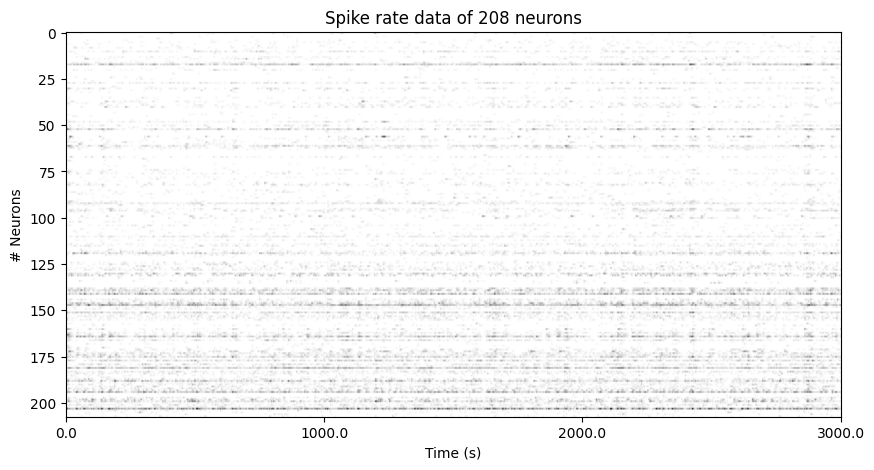

In [16]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,:30*FS], aspect = 'auto', vmax = np.round(100*neural_data[:,:30*FS].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,30*FS, 4))
ax1.set_xticklabels(np.linspace(0,30*FS, 4))
ax1.set_title('Spike rate data of 208 neurons')

In [153]:
# Split data and labels into train/validation

split_idx = int(0.8 * neural_data.shape[1])
# suggestion: 5%-20% depending on your dataset size; note that this splits the
# into an early and late part, which might not be ideal for your data/experiment!
# As a more involved alternative, consider e.g. a nested time-series split.

train_data = neural_data.T[:split_idx]
valid_data = neural_data.T[split_idx:]

In [157]:
train_data.shape

(1999200, 208)

In [158]:
valid_data.shape

(499800, 208)

In [24]:
import cebra.models
print(str(len(cebra.models.get_options())) + ' different models')
print(cebra.models.get_options())
print(str(len(cebra.models.get_options('resample*'))) + ' resample models')
print(cebra.models.get_options('resample*'))
print(str(len(cebra.models.get_options('offset*'))) + ' offset models')
print(cebra.models.get_options('offset*'))
print(str(len(cebra.models.get_options('supervised*'))) + ' supervised models')
print(cebra.models.get_options('supervised*'))


147 different models
['offset10-model', 'offset10-model-mse', 'offset5-model', 'offset1-model-mse', 'offset1-model', 'offset1-model-v2', 'offset1-model-v3', 'offset1-model-v4', 'offset1-model-v5', 'offset40-model-4x-subsample', 'resample-model', 'offset20-model-4x-subsample', 'resample5-model', 'offset4-model-2x-subsample', 'resample1-model', 'supervised10-model', 'supervised1-model', 'offset36-model', 'offset36-model-dropout', 'offset36-model-more-dropout', 'offset40-model', 'offset50-model', 'offset15-model', 'offset20-model', 'offset10-model-mse-tanh', 'offset1-model-mse-tanh', 'offset1-model-mse-clip-1000-1000', 'offset1-model-mse-clip-1000-100', 'offset1-model-mse-clip-1000-50', 'offset1-model-mse-clip-1000-25', 'offset1-model-mse-clip-1000-20', 'offset1-model-mse-clip-1000-15', 'offset1-model-mse-clip-1000-10', 'offset1-model-mse-clip-1000-5', 'offset1-model-mse-clip-1000-1', 'offset1-model-mse-clip-100-1000', 'offset1-model-mse-clip-100-100', 'offset1-model-mse-clip-100-50', 'of

Defining CEBRA model for time-contrastive learning
in model.py, all different model architectures of CEBRA are defined
offset parameter is a specification of the offset to the left and right of the signal due to the network's receptive field. The offset specifies the relation between the input and output times, ``in_time - out_time = len(offset)``. (in cebra/models/model.py l74)

Exploring the effect of incresing the dimensions

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      output_dimension=3, time_offsets=10)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 3D')

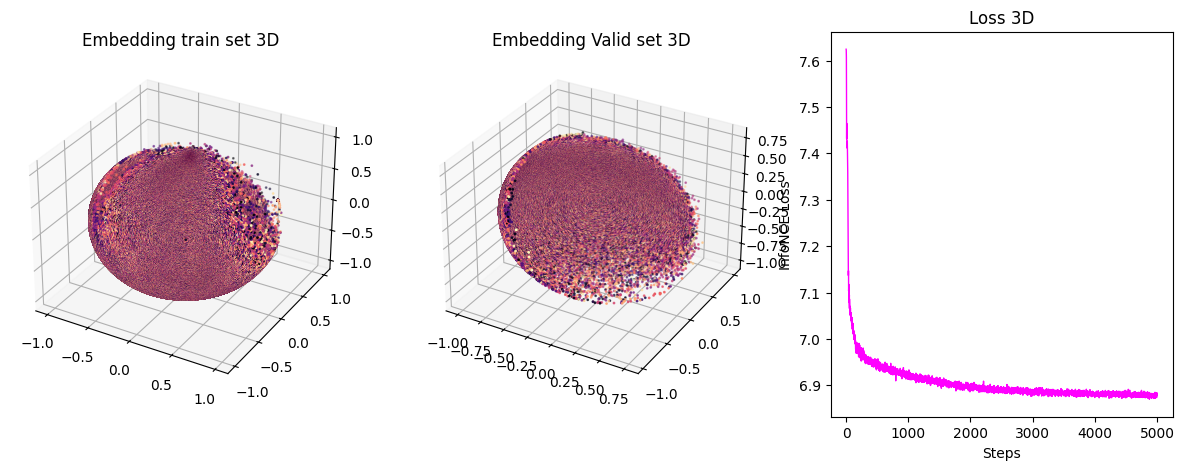

In [162]:
Output_dim = 3
cebra_3D = CEBRA(
    model_architecture = "offset10-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 10, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_3D)

# fit the model
print('Fitting the model')
cebra_3D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_3D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
ax1.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_3D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
ax2.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_3D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      output_dimension=5, time_offsets=10)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 5D')

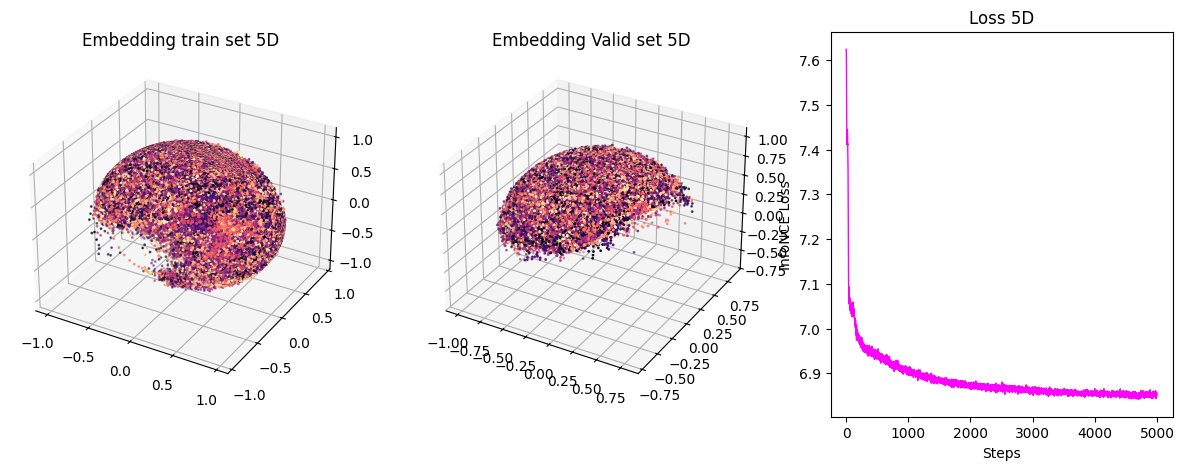

In [163]:
Output_dim = 5
cebra_5D = CEBRA(
    model_architecture = "offset10-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 10, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_5D)

# fit the model
print('Fitting the model')
cebra_5D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_5D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
ax1.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_5D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
ax2.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_5D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      output_dimension=10, time_offsets=10)
Fitting the model
calculating the embedding
plotting the embedding
plotting the Loss
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 10D')

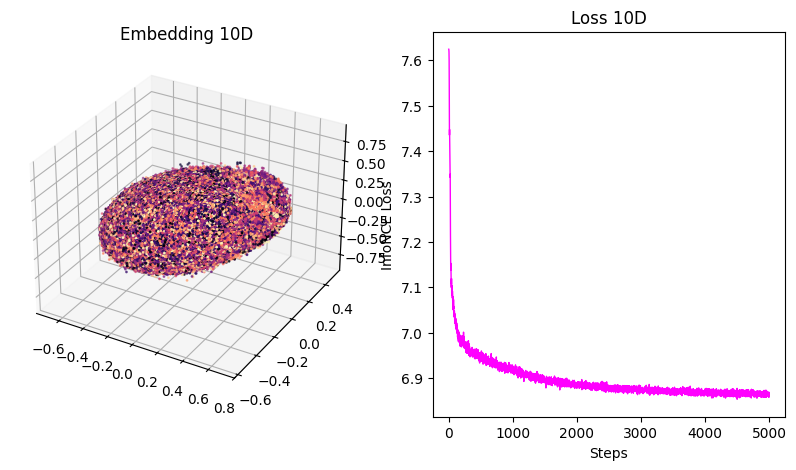

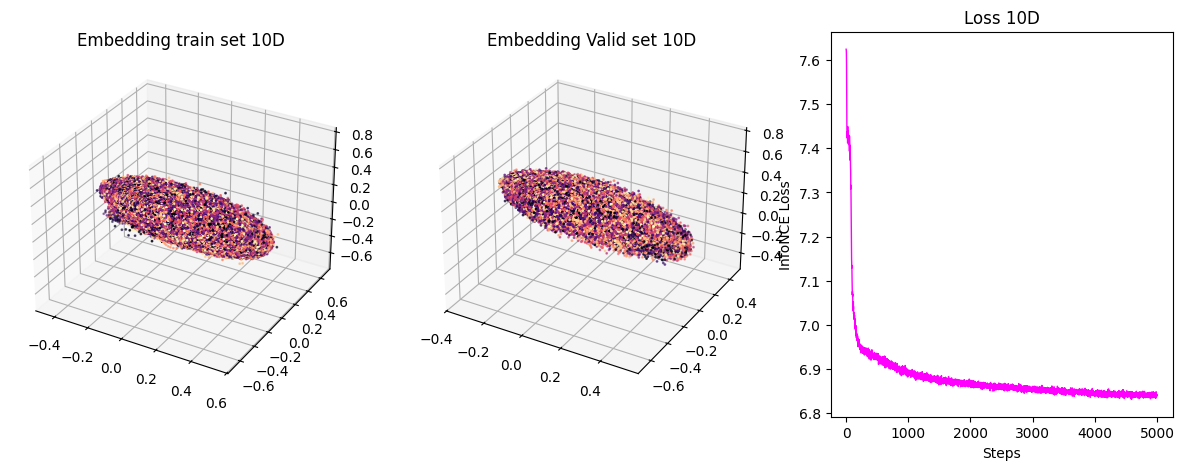

In [164]:
Output_dim = 10
cebra_10D = CEBRA(
    model_architecture = "offset10-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 10, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_10D)

# fit the model
print('Fitting the model')
cebra_10D.fit(neural_data.T)

# obtain the embedding
print('calculating the embedding')
embedding = cebra_10D.transform(neural_data.T)
assert(embedding.shape == (neural_data.shape[1],Output_dim))

# plot the embedding
print('plotting the embedding')
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1,2,1, projection='3d') # Initialize 3D axes
ax1.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(1000),2499), s=1)
ax1.set_title("Embedding " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax2 = fig.add_subplot(1,2,2)
cebra.plot_loss(cebra_10D, ax=ax2)
ax2.set_title("Loss " + str(Output_dim) + "D")# fit the model
print('Fitting the model')
cebra_10D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_10D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
ax1.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_10D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
ax2.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_10D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      output_dimension=20, time_offsets=10)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 20D')

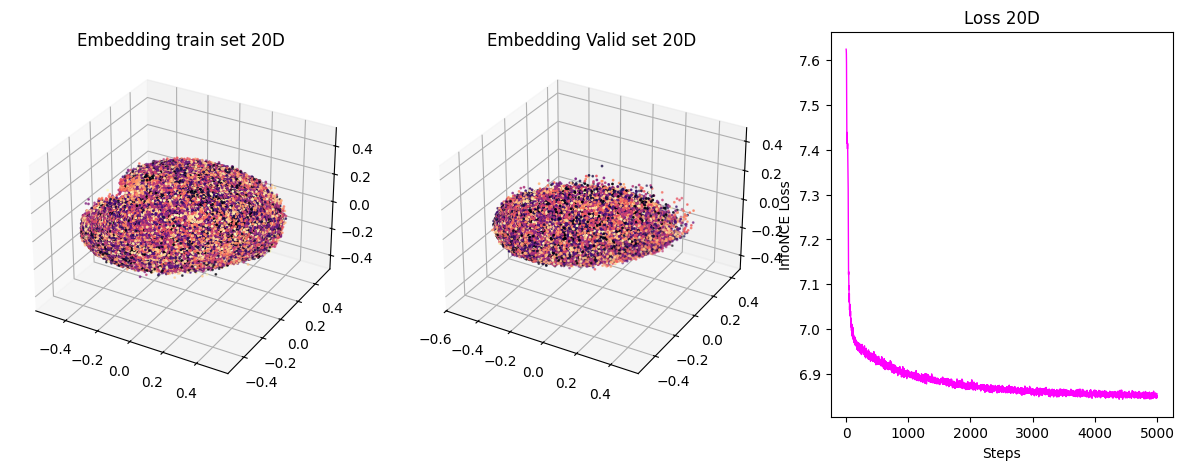

In [165]:
Output_dim = 20
cebra_20D = CEBRA(
    model_architecture = "offset10-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 10, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_20D)

# fit the model
print('Fitting the model')
cebra_20D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_20D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
ax1.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_20D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
ax2.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_20D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      output_dimension=50, time_offsets=10)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 50D')

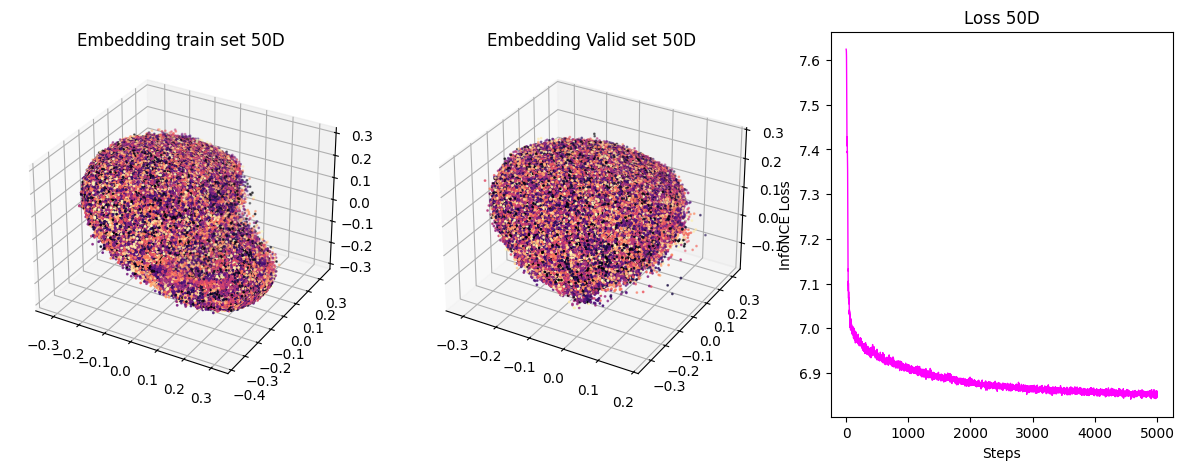

In [166]:
Output_dim = 50
cebra_50D = CEBRA(
    model_architecture = "offset10-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 10, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_50D)

# fit the model
print('Fitting the model')
cebra_50D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_50D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
ax1.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_50D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
ax2.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_50D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      output_dimension=100, time_offsets=10)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 100D')

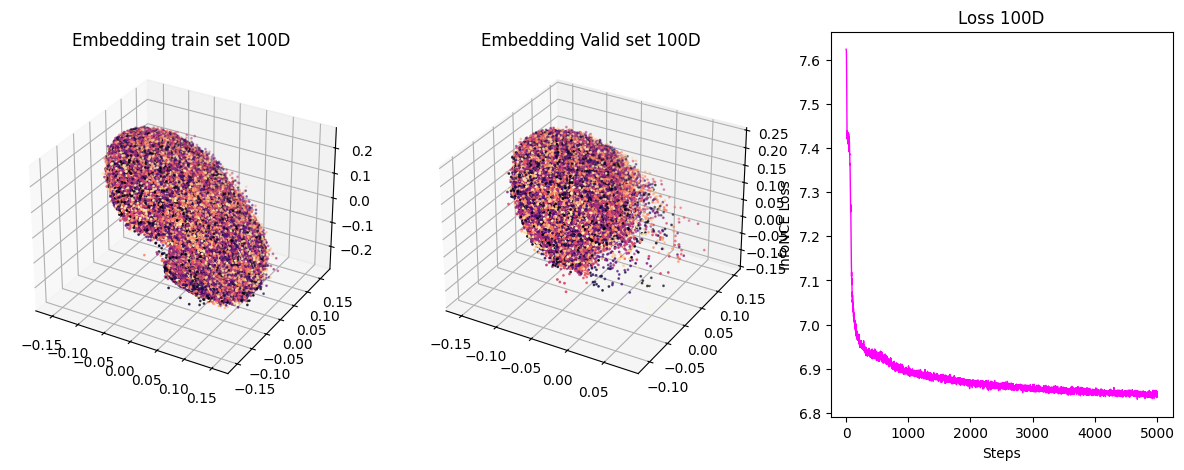

In [173]:
Output_dim = 100
cebra_100D = CEBRA(
    model_architecture = "offset10-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 10, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_100D)

# fit the model
print('Fitting the model')
cebra_100D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_100D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
ax1.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_100D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
ax2.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_100D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      output_dimension=150, time_offsets=10)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 150D')

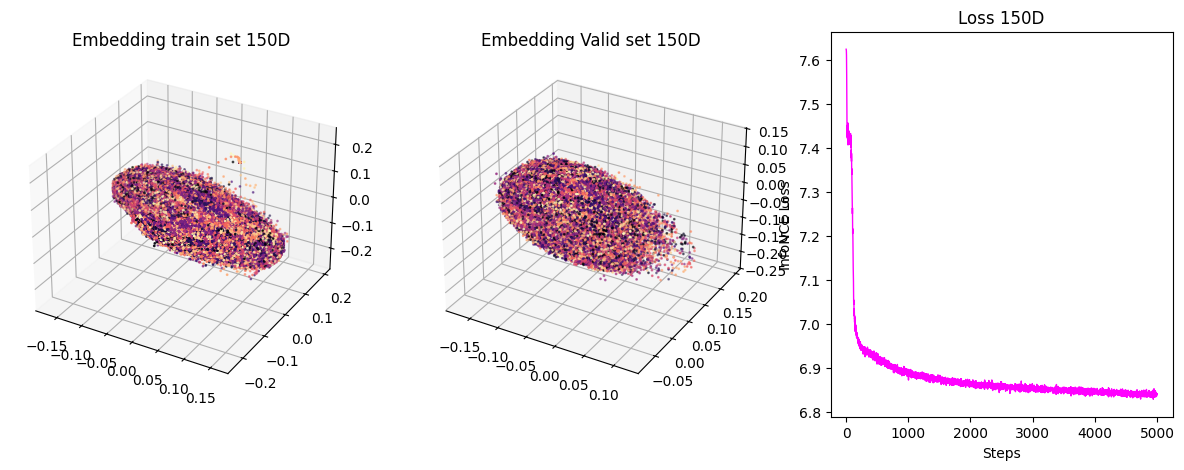

In [174]:
Output_dim = 150
cebra_150D = CEBRA(
    model_architecture = "offset10-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 10, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_150D)

# fit the model
print('Fitting the model')
cebra_150D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_150D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
ax1.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_150D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
ax2.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_150D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset10-model',
      output_dimension=200, time_offsets=10)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 200D')

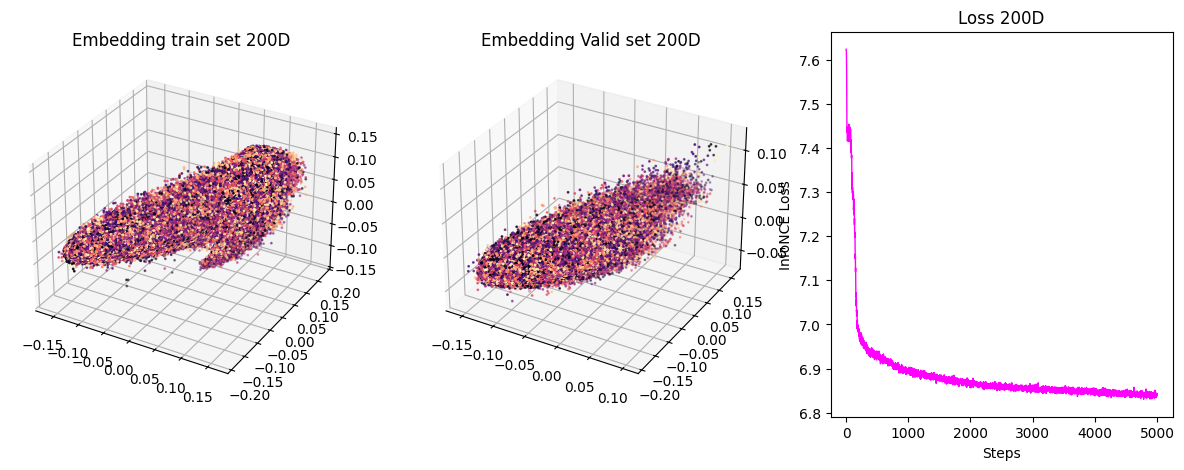

In [175]:
Output_dim = 200
cebra_200D = CEBRA(
    model_architecture = "offset10-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 10, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_200D)

# fit the model
print('Fitting the model')
cebra_200D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_200D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
ax1.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_200D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
ax2.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_200D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

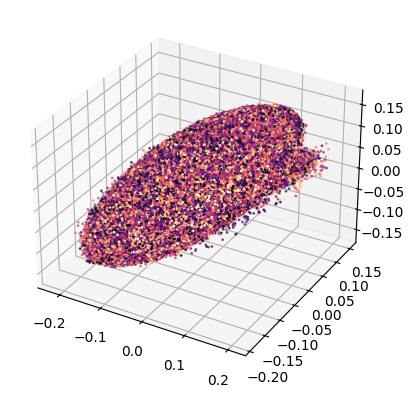

In [85]:
Dim = [3 , 4 , 5]
fig = plt.figure()
ax = fig.add_subplot(projection='3d') # Initialize 3D axes

ax.scatter(embedding[:,Dim[0]], embedding[:,Dim[1]], embedding[:,Dim[2]], cmap = 'magma', c = np.tile(np.arange(1000),2499), s=1)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

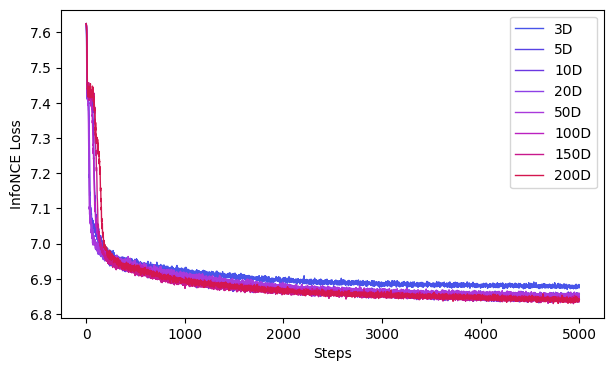

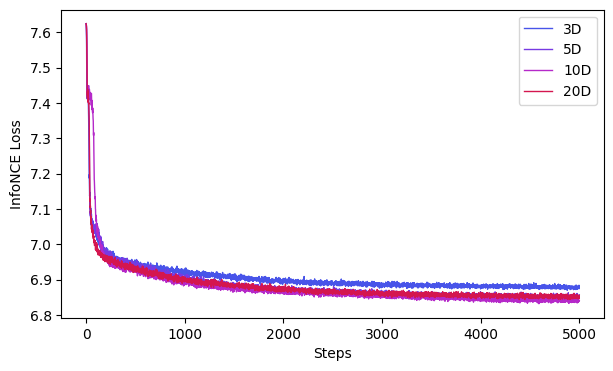

In [176]:
# compare Losses
# Labels to be used for the legend of the plot
labels = ["3D","5D", "10D", "20D", "50D", "100D", "150D", "200D"]

cebra.compare_models([cebra_3D, cebra_5D, cebra_10D, cebra_20D, cebra_50D, cebra_100D, cebra_150D, cebra_200D], labels)
# Labels to be used for the legend of the plot
labels = ["3D", "5D", "10D", "20D"]

cebra.compare_models([cebra_3D, cebra_5D, cebra_10D, cebra_20D], labels)

Text(0.5, 0, 'Dimensions')

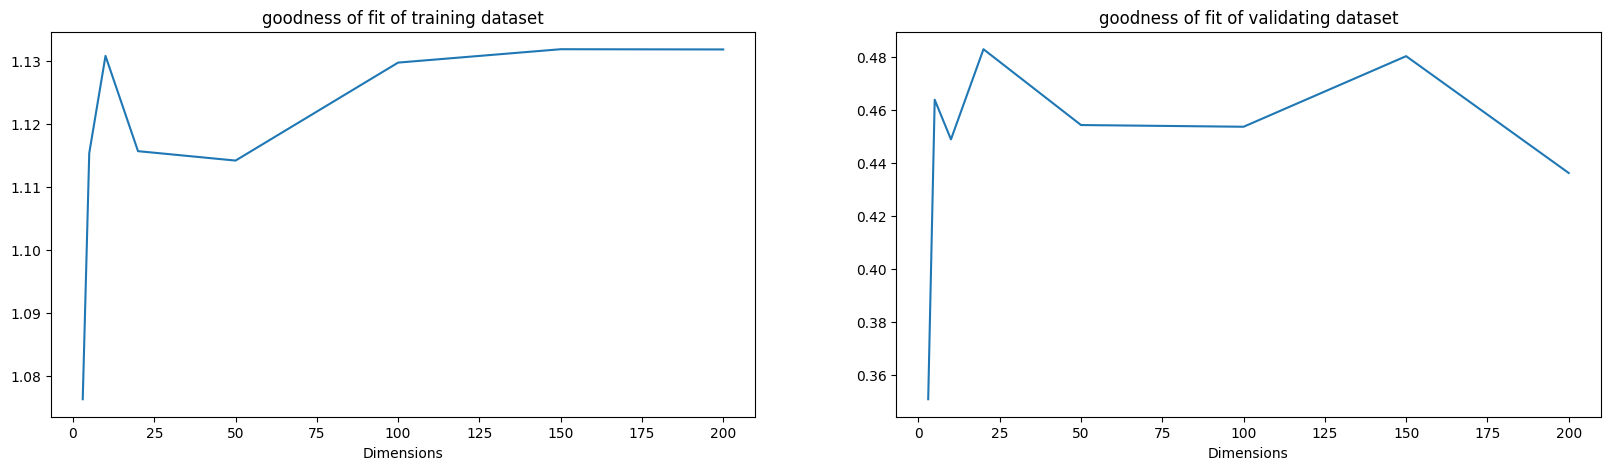

In [181]:
# Evaluate the model performance
goodness_of_fit_train = []
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_3D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_5D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_10D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_20D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_50D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_100D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_150D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_200D,
                                                     train_data))
fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot([3,5,10,20,50,100,150,200], goodness_of_fit_train)
ax1.set_title('goodness of fit of training dataset')
ax1.set_xlabel('Dimensions')

goodness_of_fit_valid = []
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_3D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_5D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_10D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_20D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_50D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_100D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_150D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_200D,
                                                     valid_data))
ax2 = fig.add_subplot(1,2,2)
ax2.plot([3,5,10,20,50,100,150,200], goodness_of_fit_valid)
ax2.set_title('goodness of fit of validating dataset')
ax2.set_xlabel('Dimensions')

5D seems to be the best model

calculating the validating embedding
plotting the embedding for validating data


Text(0.5, 0.92, 'Embedding Valid set 5D, Dim1 Dim4 and Dim5')

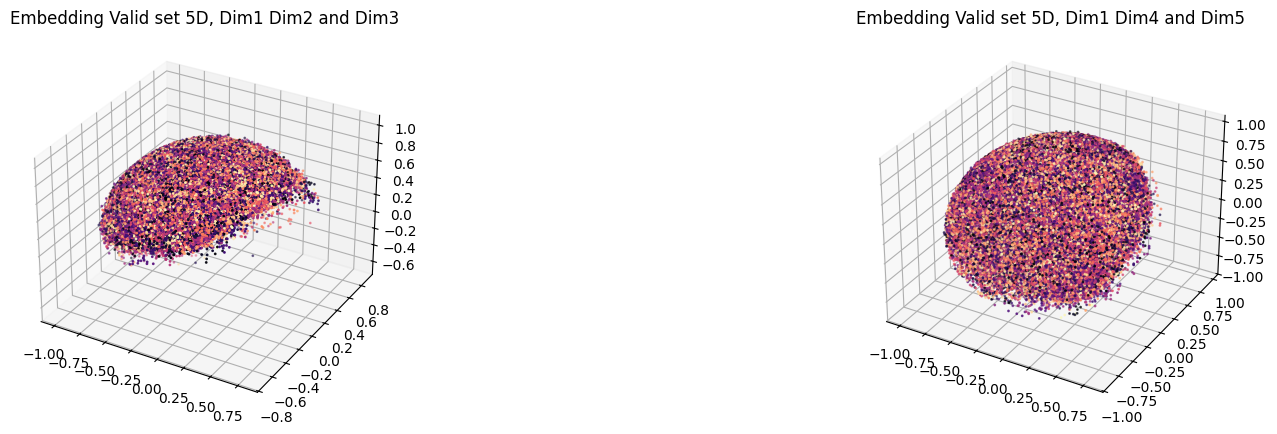

In [183]:
# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_5D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],5))

# plot the embedding for validating set
print('plotting the embedding for validating data')
fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1, projection='3d') # Initialize 3D axes
ax1.scatter(embedding[:,0], embedding[:,1], embedding[:,2], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax1.set_title("Embedding Valid set 5D, Dim1 Dim2 and Dim3")
ax2 = fig.add_subplot(1,2,2, projection='3d') # Initialize 3D axes
ax2.scatter(embedding[:,0], embedding[:,3], embedding[:,4], cmap = 'magma', c = np.tile(np.arange(100),int(embedding.shape[0]/100)), s=1)
ax2.set_title("Embedding Valid set 5D, Dim1 Dim4 and Dim5")